## Project Introduction

 ##### A client wants to gain meaningful insights into its e-commerce business performance and identify opportunities for future growth. The objective is to analyze sales, products, website activity, marketing performance, and customer behaviour to understand what is driving the business and where improvements are needed.

| Stakeholder | Role | Responsibilities |
|:---|:---|:---|
| Cindy Sharp | CEO | Overall business performance |
| Morgan Rockwell | Website Manager | Website traffic & conversion |
| Tom Parmesan | Marketing Director | Marketing effectiveness |

##### Nature of Business : E-commerce startup that sells stuffed animal toys through its online platform

##### Business Problem: Client needs to understand its sales, product, website, customer, and marketing performance to identify areas of improvement and opportunities for business growth.

###### Which products generate the highest sales and revenue?
###### Which channels bring the most customers?
###### What is the website conversion rate?
###### Which marketing sources perform best?
###### Which stores/products/customers have the strongest performance?
###### Where are the major opportunities for growth?

In [62]:
import pyodbc
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import 

In [13]:
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=EKTA\SQLEXPRESS;"
    "DATABASE=EcommerceAnalytics;"
    "Trusted_Connection=yes;"    
)

In [14]:
conn_str

'DRIVER={ODBC Driver 17 for SQL Server};SERVER=EKTA\\SQLEXPRESS;DATABASE=EcommerceAnalytics;Trusted_Connection=yes;'

In [15]:
con = pyodbc.connect(conn_str)

In [18]:
engine = create_engine("mssql+pyodbc://",creator = lambda:con)

In [20]:
orders = pd.read_sql("SELECT * FROM orders",engine)
order_items = pd.read_sql("SELECT * FROM order_items",engine)
order_item_refunds = pd.read_sql("SELECT * FROM order_item_refunds",engine)
products = pd.read_sql("SELECT * FROM products",engine)
website_pageviews = pd.read_sql("SELECT * FROM website_pageviews",engine)
website_sessions = pd.read_sql("SELECT * FROM website_sessions",engine)

In [24]:
print("orders:",orders.shape)
print("order_items:",order_items.shape)
print("order_item_refunds:",order_item_refunds.shape)
print("products:",products.shape)
print("website_pageviews:",website_pageviews.shape)
print("website_sessions:",website_sessions.shape)

orders: (32313, 8)
order_items: (40025, 7)
order_item_refunds: (1731, 5)
products: (4, 3)
website_pageviews: (1188124, 4)
website_sessions: (472871, 9)


#### Checking Null Values

In [34]:
orders.isna().sum()

order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

In [35]:
order_items.isna().sum()

order_item_id      0
created_at         0
order_id           0
product_id         0
is_primary_item    0
price_usd          0
cogs_usd           0
dtype: int64

In [36]:
products.isna().sum()

product_id      0
created_at      0
product_name    0
dtype: int64

In [37]:
website_pageviews.isna().sum()

website_pageview_id    0
created_at             0
website_session_id     0
pageview_url           0
dtype: int64

In [38]:
website_sessions.isna().sum()

website_session_id    0
created_at            0
user_id               0
is_repeat_session     0
utm_source            0
utm_campaign          0
utm_content           0
device_type           0
http_referer          0
dtype: int64

In [39]:
order_item_refunds.isna().sum()

order_item_refund_id    0
created_at              0
order_item_id           0
order_id                0
refund_amount_usd       0
dtype: int64

##### Checking Duplicates

In [50]:
print("orders:",orders.duplicated().sum(), "duplicate values")
print("order_items:",order_items.duplicated().sum(), "duplicate values")
print("order_item_refunds:",order_item_refunds.duplicated().sum(), "duplicate values")
print("products:",products.duplicated().sum(), "duplicate values")
print("website_pageviews:",website_pageviews.duplicated().sum(), "duplicate values")
print("website_sessions:",website_sessions.duplicated().sum(), "duplicate values")

orders: 0 duplicate values
order_items: 0 duplicate values
order_item_refunds: 0 duplicate values
products: 0 duplicate values
website_pageviews: 0 duplicate values
website_sessions: 0 duplicate values


##### Exploratory Data Analysis (EDA)

###### Session Analysis → traffic & conversion

In [51]:
website_sessions.columns

Index(['website_session_id', 'created_at', 'user_id', 'is_repeat_session',
       'utm_source', 'utm_campaign', 'utm_content', 'device_type',
       'http_referer'],
      dtype='object')

In [61]:
Total_Sessions=website_sessions['website_session_id'].count()
Conversion_rate=web_analysis["Converted"].mean() * 100

In [67]:
web_analysis=website_sessions.merge(orders[['order_id','website_session_id']],
                       on = 'website_session_id', how = 'left')

web_analysis['Converted'] = web_analysis['order_id'].notna().astype(int)

In [67]:
Device_conversion_rate = web_analysis.groupby('device_type').agg(
    Sessions= ('website_session_id','count'),
    Total_orders=('Converted','sum'),
    Conversion_rate=('Converted','mean'))

Device_conversion_rate['Conversion_rate']= (Device_conversion_rate['Conversion_rate'] * 100).round(2)

In [72]:
Device_conversion_rate

,Sessions,Total_orders,Conversion_rate
device_type,,,
desktop,327027,27805,8.50
mobile,145844,4508,3.09


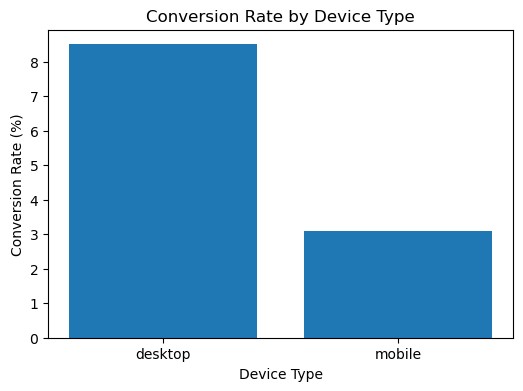

In [78]:
plt.figure(figsize=(6, 4))

plt.bar(
    Device_conversion_rate.index,
    Device_conversion_rate["Conversion_rate"]
)

plt.title("Conversion Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate (%)")

plt.show()

###### Marketing Analysis → UTM sources/campaigns

In [109]:
web_analysis['utm_source'] = web_analysis['utm_source'].replace('NULL', 'other')
web_analysis['utm_campaign'] = web_analysis['utm_campaign'].replace('NULL', 'other')

In [100]:
Utm_Source_analysis=web_analysis.groupby('utm_source').agg(
   Total_Sessions = ('website_session_id','count'),
    Total_orders = ('Converted','sum'),
    Conversion_rate = ('Converted','mean')
)

Utm_Source_analysis['Conversion_rate']= (Utm_Source_analysis['Conversion_rate'] * 100 ).round(2)

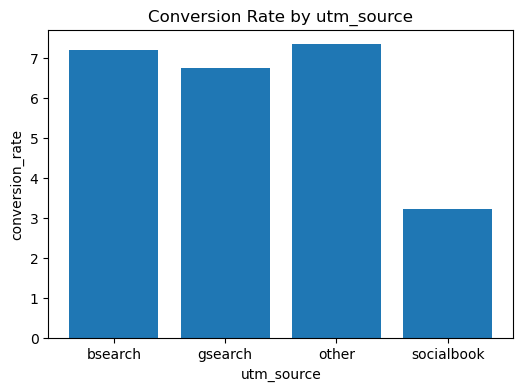

In [103]:
plt.figure(figsize=(6, 4))
plt.bar(
    Utm_Source_analysis.index,
    Utm_Source_analysis['Conversion_rate']
)
plt.title('Conversion Rate by utm_source')
plt.xlabel('utm_source')
plt.ylabel('conversion_rate')
plt.show()

In [110]:
utm_campaign_analysis = web_analysis.groupby('utm_campaign').agg(
   Total_Sessions = ('website_session_id','count'),
    Total_orders = ('Converted','sum'),
    Conversion_rate = ('Converted','mean')
)

utm_campaign_analysis['Conversion_rate']= (utm_campaign_analysis['Conversion_rate'] * 100 ).round(2)

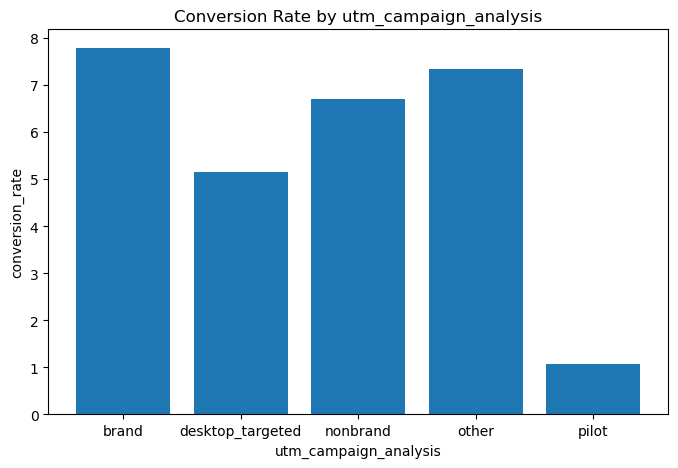

In [111]:
plt.figure(figsize=(8, 5))
plt.bar(
    utm_campaign_analysis.index,
    utm_campaign_analysis['Conversion_rate']
)
plt.title('Conversion Rate by utm_campaign_analysis')
plt.xlabel('utm_campaign_analysis')
plt.ylabel('conversion_rate')
plt.show()

In [112]:
web_analysis.columns

Index(['website_session_id', 'created_at', 'user_id', 'is_repeat_session',
       'utm_source', 'utm_campaign', 'utm_content', 'device_type',
       'http_referer', 'order_id', 'Converted'],
      dtype='object')

In [117]:
repeat_session_analysis = web_analysis.groupby('is_repeat_session').agg(
    Total_Session = ('website_session_id','sum'),
    total_session = ('website_session_id','count'),
    conversion_rate = ('Converted','mean')
)

repeat_session_analysis['conversion_rate']=(repeat_session_analysis['conversion_rate']*100).round(2)

In [118]:
repeat_session_analysis

,Total_Session,total_session,conversion_rate
is_repeat_session,,,
0,91189633891,394318,6.64
1,20614093865,78553,7.83


In [121]:
web_analysis.columns

Index(['website_session_id', 'created_at', 'user_id', 'is_repeat_session',
       'utm_source', 'utm_campaign', 'utm_content', 'device_type',
       'http_referer', 'order_id', 'Converted'],
      dtype='object')

#### Customer Conversion Prediction

##### Goal: Predict whether a website session is likely to convert into an order.

In [124]:
web_analysis['utm_content']= web_analysis['utm_content'].replace("NULL","Other")


In [133]:
model_data = web_analysis[
    ['is_repeat_session','utm_source', 'utm_campaign', 'utm_content', 'device_type','Converted']
].copy()

In [135]:
model_data=pd.get_dummies(model_data,
               columns = ['utm_source', 'utm_campaign', 'utm_content', 'device_type'],
              drop_first = True, dtype=int)

In [138]:
X= model_data.drop(columns = 'Converted')
y = model_data['Converted']

In [161]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.metrics import roc_auc_score


In [143]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [151]:
model = LogisticRegression(class_weight='balanced')

In [152]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [168]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [170]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.3702881311128734
Precision: 0.0873837815950538
Recall: 0.8545537618032287
F1 Score: 0.15855433262217952
ROC-AUC: 0.6108044456326147


The Logistic Regression model achieved a ROC-AUC of 0.61, indicating limited ability to distinguish between converting and non-converting sessions. While the model achieved high recall (85.46%), its low precision (8.74%) resulted in a low F1-score.Model has limited predictive power.

#### Predictive Model 2 - Linear Regression

Predict Order Values

In [171]:
orders.columns

Index(['order_id', 'created_at', 'website_session_id', 'user_id',
       'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd'],
      dtype='object')

In [172]:
website_sessions.columns

Index(['website_session_id', 'created_at', 'user_id', 'is_repeat_session',
       'utm_source', 'utm_campaign', 'utm_content', 'device_type',
       'http_referer'],
      dtype='object')

In [173]:
order_model=orders.merge(website_sessions[
    ['website_session_id','is_repeat_session','utm_source', 'utm_campaign','utm_content','device_type']
    ],on='website_session_id',
             how = 'left')

In [179]:
order_model['utm_source']= order_model['utm_source'].replace('NULL', 'other')
order_model['utm_content']= order_model['utm_content'].replace('NULL', 'other')
order_model['utm_campaign']= order_model['utm_campaign'].replace('NULL', 'other')

In [181]:
order_model.columns

Index(['order_id', 'created_at', 'website_session_id', 'user_id',
       'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd',
       'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content',
       'device_type'],
      dtype='object')

In [183]:
model_data=order_model[['primary_product_id', 'items_purchased','price_usd','is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content',
       'device_type']].copy()

In [193]:
model_data= pd.get_dummies(model_data,columns= [
              'primary_product_id', 'utm_source', 'utm_campaign', 'utm_content',
              'device_type'],
               drop_first=True,dtype=int
              )

In [194]:
X=model_data.drop(columns='price_usd')
y=model_data['price_usd']

In [195]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
                       r2_score, 
                       mean_squared_error,
                       mean_absolute_error)
                       

In [203]:
X_data_train,X_data_test,y_data_train,y_data_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [204]:
lr=LinearRegression()
lr.fit(X_data_train,y_data_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [205]:
prediction=lr.predict(X_data_test)

In [206]:
print("R2 Score", r2_score(y_data_test,prediction))
print("MSE",mean_squared_error(y_data_test,prediction))
print("MAE",mean_absolute_error(y_data_test,prediction))
print("RMSE", np.sqrt(mean_squared_error(y_data_test,prediction)))


R2 Score 0.9104791232739701
MSE 28.07995486579135
MAE 2.5868960591095953
RMSE 5.299052261092671


The Linear Regression model achieved an R² score of 0.91, indicating that it explains approximately 91% of the variation in order values. The model has a Mean Absolute Error of 2.59, meaning that the predicted order values differ from the actual values by approximately 2.59 on average.

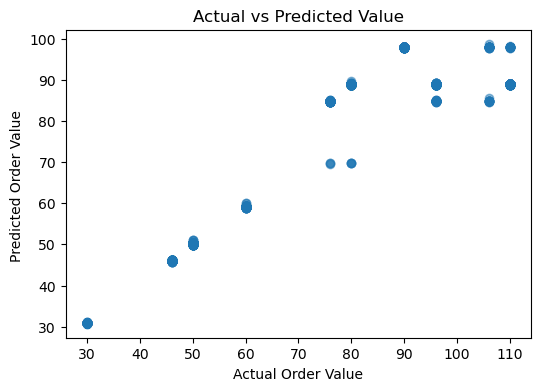

In [210]:
plt.figure(figsize=(6, 4))

plt.scatter(
    y_data_test,
    prediction,
    alpha=0.5
)

plt.xlabel("Actual Order Value")
plt.ylabel("Predicted Order Value ")
plt.title("Actual vs Predicted Value")

plt.show()

Showing a strong relationship between actual and predicted values. Some variation is visible, but overall the model performs well.

### Business Insights:

- **Conversion:** The overall conversion rate was 6.83%, showing a large opportunity to convert more website visitors into customers.
- **Marketing:** Marketing sources and campaigns showed different levels of performance, so budget can be shifted towards better-performing channels.
- **Device Performance:** Desktop has a higher conversion rate(8.5%) than mobile(3.1%). Improving the mobile website experience, navigation and checkout process can help increase mobile conversions and overall sales.
- **Product Expansion:** With only 4 products, the product range is quite limited. Adding more varieties can give users more options to choose from and create more opportunities for sales.
- **Promotional Offers:** Introducing attractive offers and discounts can encourage customers to purchase more, increase their purchasing frequency, and ultimately drive higher sales.
- **Repeat Visitors:** Repeat sessions can be targeted with personalised offers and product recommendations to encourage purchases.
- **Conversion Modeling:** Logistic Regression achieved 85.46% recall and 61.08% ROC-AUC, showing it can identify most potential converters but with lower precision.
- **Order Value Modeling:** Linear Regression achieved 91.05% R² with an average prediction error of around $2.59 (MAE), indicating strong order-value prediction.